In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import load_diabetes

data=load_diabetes()

In [3]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
X=data.data
y=data.target

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()


In [7]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
y_pred=lr.predict(X_test)


In [9]:
from sklearn.metrics import r2_score, mean_squared_error
print("R2_score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R2_score: 0.4526027629719197
MSE: 2900.1936284934804


In [10]:
from sklearn.linear_model import Ridge
R=Ridge(alpha=0.001)

In [11]:
R.fit(X_train, y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.001
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None

In [12]:
y_pred1=R.predict(X_test)


In [13]:
print("output score of the Ridge Regression:")

print("R2_score:", r2_score(y_test, y_pred1))
print("MSE:", mean_squared_error(y_test, y_pred1))

output score of the Ridge Regression:
R2_score: 0.453428030101933
MSE: 2895.8212380056066


linear Regression and Ridge regression works similar on the dataset reason can be the distribution of the dataset

I create the new dataset to see the changes in broder way


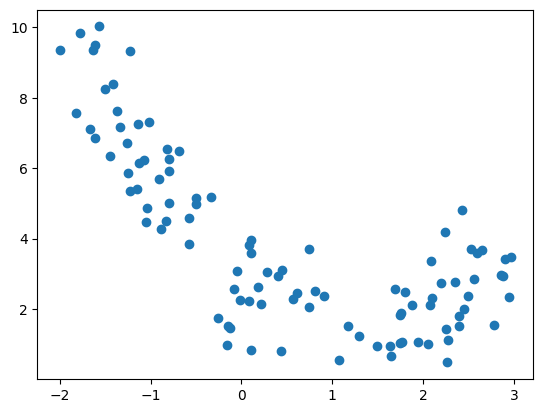

In [14]:
m=100
x1=5*np.random.rand(m,1) -2
x2=0.7*x1**2 -2*x1 +3+np.random.randn(m,1)

plt.scatter(x1,x2)
plt.show()

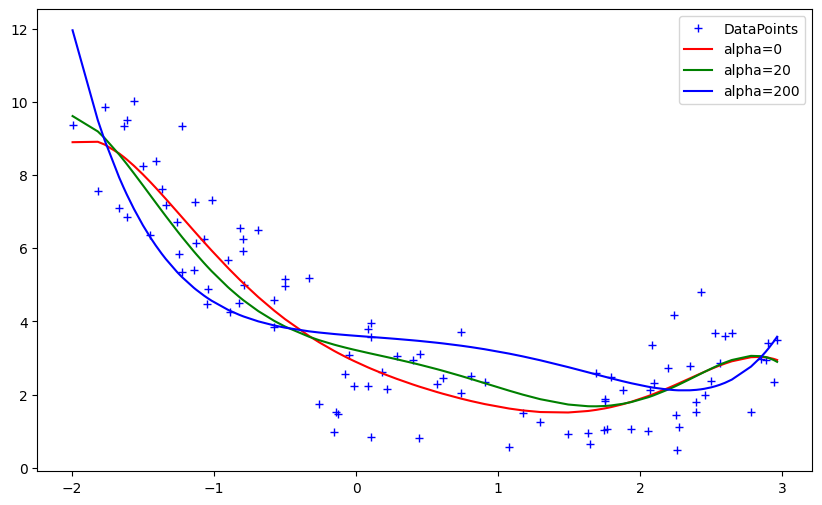

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_features', PolynomialFeatures(degree=6)),
        ("ridge", Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alpha=[0,20,200]
cs=['r','g','b']

plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+', label='DataPoints')

for a,c in zip(alpha, cs):
    preds=get_preds_ridge(x1,x2,a)

    #plot
    plt.plot(sorted(x1[:,0]), preds[np.argsort(x1[:,0])], c=c, label='alpha={}'.format(a))

plt.legend()
plt.show()

# Ridge Regression from Scratch m and b

In [18]:
from sklearn.datasets import make_regression

In [21]:
X,y= make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=29)

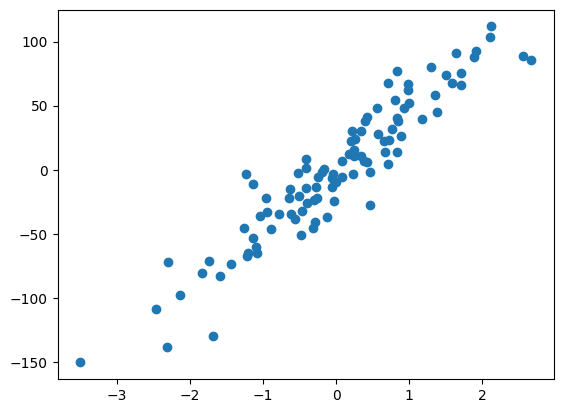

In [22]:
plt.scatter(X,y)

In [23]:
lr=LinearRegression()
lr.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
print(lr.coef_, lr.intercept_)

[44.71605039] -0.36491471831761546


In [25]:
rr=Ridge(alpha=10)
rr.fit(X,y)
print(rr.coef_, rr.intercept_)

[41.52063364] -0.2850411130744587


In [26]:
rr2=Ridge(alpha=100)
rr2.fit(X,y)
print(rr2.coef_, rr2.intercept_)

[25.26905436] 0.12118828537308457


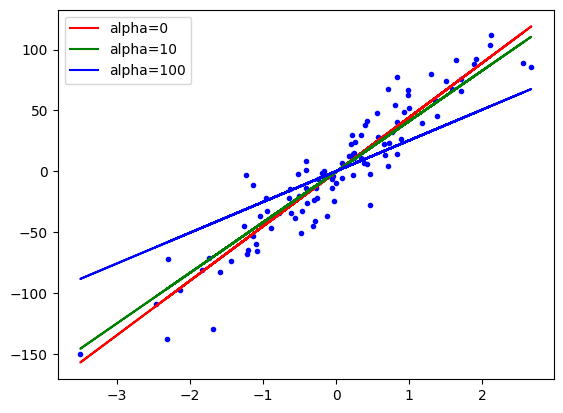

In [27]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X), color='red', label='alpha=0')
plt.plot(X,rr.predict(X), color='green', label='alpha=10')
plt.plot(X,rr2.predict(X), color='blue', label='alpha=100')
plt.legend()

In [28]:
class MeraRidge:
    def __init__(self, alpha=1.0):
        self.alpha=alpha
        self.m=None
        self.b=None

    def fit(self, X,y):
        n=X.shape[0]
        x_mean=np.mean(X)
        y_mean=np.mean(y)

        num=0
        den=0

        for i in range(n):
            num+=(X[i]-x_mean)*(y[i]-y_mean)
            den+=(X[i]-x_mean)**2

        self.m=num/(den+self.alpha)
        self.b=y_mean - self.m*x_mean
        print("m:", self.m ,"b:", self.b)

    def predict(self,X):
        return self.m*X + self.b

In [29]:
reg=MeraRidge(alpha=10)

In [30]:
reg.fit(X,y)

m: [41.52063364] b: [-0.28504111]


## for N Dimension data

In [32]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score

In [33]:
X,y=load_diabetes(return_X_y=True)

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.3, random_state=13)

In [39]:
reg=Ridge(alpha=0.1, solver='cholesky')

In [40]:
reg.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'cholesky'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",No

In [41]:
y_pred=reg.predict(X_test)
r2_score(y_test, y_pred)

0.4508989510462177

In [42]:
print(reg.coef_, reg.intercept_)

[  -2.94536746 -222.04694288  515.11902653  346.27911006  -73.48621264
 -132.32693091 -186.09213848  102.46624342  445.25083316  106.14374981] 150.9634372730018


In [49]:
class MeraNRidge:
    def __init__(self, alpha=1.0):
        self.alpha=alpha
        self.w=None
        self.b=None
    
    def fit(self,X,y):
        n=X.shape[0]
        X_new = np.hstack((np.ones((n, 1)), X))
        I=np.identity(X_new.shape[1])
        result=np.linalg.inv(np.dot(X_new.T, X_new) + self.alpha*I).dot(X_new.T).dot(y)
        self.b=result[0]
        self.w=result[1:]

        #print("w:", self.w, "b:", self.b)
    
    def predict(self,X):
        return np.dot(X, self.w) + self.b



In [50]:
reg=MeraNRidge(alpha=10)
reg.fit(X_train,y_train)
y_pred=reg.predict(X_test)
print("R2_score: ",r2_score(y_test, y_pred))
print(reg.w, reg.b)

R2_score:  0.15899448519909354
[ 14.48847024  -2.21672149  60.29674882  46.49811731  16.35446257
  10.4115007  -31.17072942  34.30718475  51.74337923  35.72769195] 147.5110941616983


# Ridge Regression using the gradient Descent

In [51]:
from sklearn.linear_model import SGDRegressor

In [78]:
reg=SGDRegressor(penalty='l2', max_iter=800, eta0=0.01, learning_rate='constant', alpha=0.01)

In [79]:
reg.fit(X_train, y_train)
y_pred=reg.predict(X_test)
print("R2_score: ", r2_score(y_test, y_pred))
print(reg.coef_, reg.intercept_)

R2_score:  0.29187922062901017
[ 27.39314367 -10.37878791 129.57100091  98.5067246   27.30756856
  13.51438244 -64.42139479  67.12477817 108.50851284  72.24383606] [156.91359159]
